# Worksheet: Intro to Pytorch

Use torch to train a simple linear regression model, i.e. the model is $y = kx+b$. This worksheet does not involve `nn Module`. 

Deliverables: 1) Please report iterations, training losses, predicted k, and predicted b after each iteration/every 100 iteartions (2 pts); 2) visualize training loss (2 pts) 3) visualize test loss (2 pts)

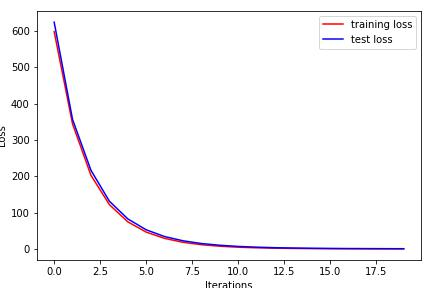

#### Grading:
Participation and deliverables. 

0, 	598.8665771484375, 	-1.7959117889404297, 	-16.065486907958984
1, 	344.24884033203125, 	-7.22869348526001, 	-12.835834503173828
2, 	202.98486328125, 	-3.5727317333221436, 	-10.306440353393555
3, 	122.22515869140625, 	-5.985964298248291, 	-8.246365547180176
4, 	74.83067321777344, 	-4.355737209320068, 	-6.622438430786133
5, 	46.406715393066406, 	-5.426859378814697, 	-5.306994438171387
6, 	29.063810348510742, 	-4.69926643371582, 	-4.265350341796875
7, 	18.341386795043945, 	-5.174154758453369, 	-3.4247591495513916
8, 	11.646472930908203, 	-4.848998069763184, 	-2.75703501701355
9, 	7.436028003692627, 	-5.059200286865234, 	-2.219604253768921
10, 	4.774270057678223, 	-4.913621425628662, 	-1.7917615175247192
11, 	3.0853097438812256, 	-5.006443977355957, 	-1.4480315446853638
12, 	2.010802984237671, 	-4.941093921661377, 	-1.1739758253097534
13, 	1.325941562652588, 	-4.981942176818848, 	-0.9540777802467346
14, 	0.8888663649559021, 	-4.952497482299805, 	-0.7785677909851074
15, 	0.60967183113098

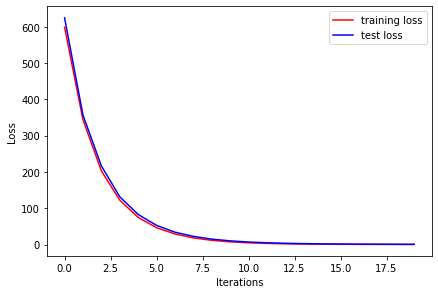

In [29]:
import torch
import numpy as np
import matplotlib.pyplot as plt
 
X = torch.arange(-5, 5, 0.1).view(-1, 1)
func = -5 * X
Y = func + 0.4 * torch.randn(X.size())

X_test = torch.linspace(-5,5,1024).view(-1,1)
Y_test = -5 * X_test + 0.4
 
# defining the function for forward pass for prediction
def forward(x):
    return w * x + b
 
# evaluating data points with Mean Square Error.
def criterion(y_pred, y):
    return torch.mean((y_pred - y) ** 2)
 
w = torch.tensor(-10.0, requires_grad=True)
b = torch.tensor(-20.0, requires_grad=True)
 
step_size = 0.1
loss_list = []
iter = 20

loss_test_list = []

for i in range (iter):    
    # making predictions with forward pass (training)
    Y_pred = forward(X)
    
    # making predictions on test data
    y_pred = forward(X_test)
    loss_test = criterion(y_pred, Y_test)
    loss_test_list.append(loss_test.item())
    
    # calculating the loss between original and predicted data points
    loss = criterion(Y_pred, Y)
    # storing the calculated loss in a list
    loss_list.append(loss.item())
    # backward pass for computing the gradients of the loss w.r.t to learnable parameters
    loss.backward()
    # updateing the parameters after each iteration
    w.data = w.data - step_size * w.grad.data
    b.data = b.data - step_size * b.grad.data
    # zeroing gradients after each iteration
    w.grad.data.zero_()
    b.grad.data.zero_()
    # priting the values for understanding
    print('{}, \t{}, \t{}, \t{}'.format(i, loss.item(), w.item(), b.item()))
    
    
    
# visualization
plt.plot(loss_list, 'r', label='training loss')
plt.plot(loss_test_list, 'b', label='test loss')
plt.legend()
#plt.tight_layout()
#plt.grid('True', color='y')
plt.xlabel("Iterations")
plt.ylabel("Loss")
#plt.show()
plt.savefig("torch.jpg")